In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv('Customer Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [46]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [48]:
df.isnull().sum().sum()

np.int64(0)

In [49]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [50]:
df["customerID"].duplicated().sum()

np.int64(0)

In [51]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

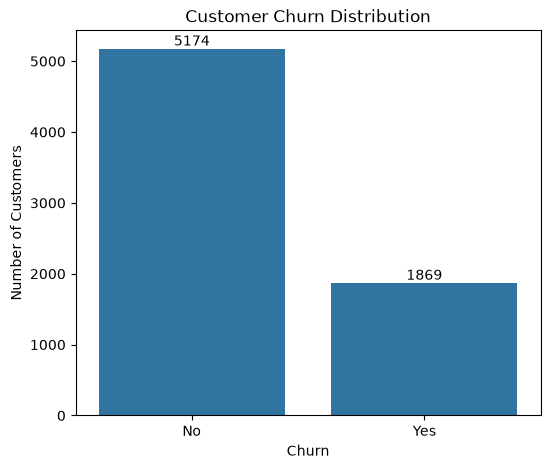

In [52]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Churn', data=df)

ax.bar_label(ax.containers[0])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

<Figure size 400x400 with 0 Axes>

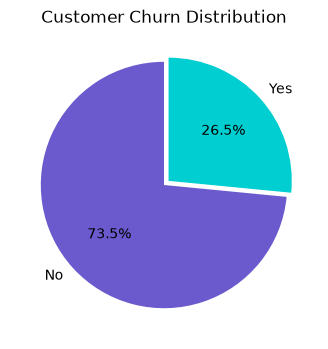

In [53]:
plt.figure(figsize=(4,4))

plt.figure(figsize=(4,4))

gb = df.groupby("Churn")["Churn"].count()

plt.pie(
    gb,
    labels=gb.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0, 0.05],
    colors=["#6A5ACD", "#00CED1"]
)

plt.title("Customer Churn Distribution")
plt.show()

from the given pie chart we can conclude that 26.54% of our customers have churned out.
not let's explore the reason behind it

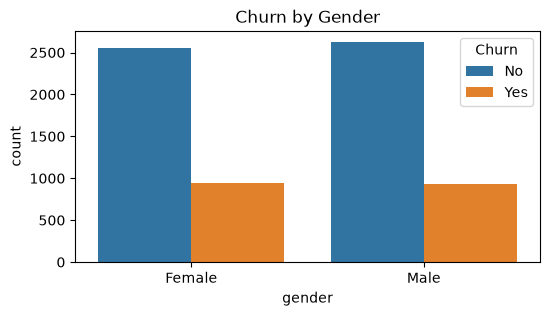

In [54]:
plt.figure(figsize = (6,3))
sns.countplot(x = "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.show()

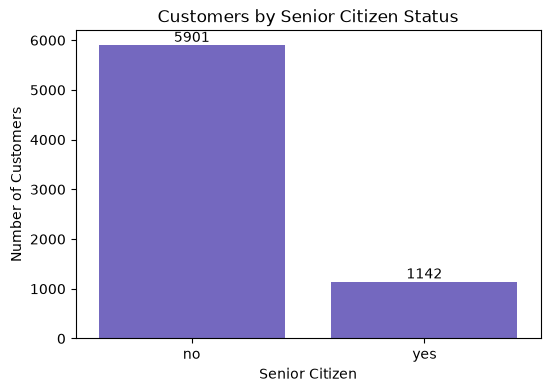

In [55]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="SeniorCitizen",
    data=df,
    color="#6A5ACD"
)

ax.bar_label(ax.containers[0])

plt.title("Customers by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

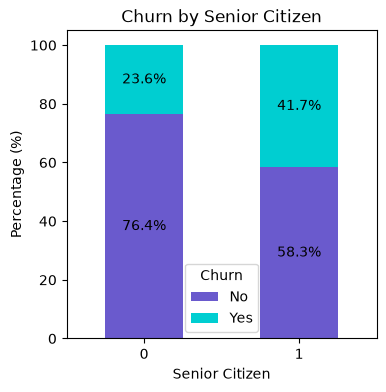

In [59]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(4, 4))

total_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#6A5ACD', '#00CED1']
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_y() + p.get_height()/2,
            f'{p.get_height():.1f}%',
            ha='center',
            va='center'
        )

plt.title('Churn by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.show()

#comparative a greater pecentage of people in senior citizen category have churned


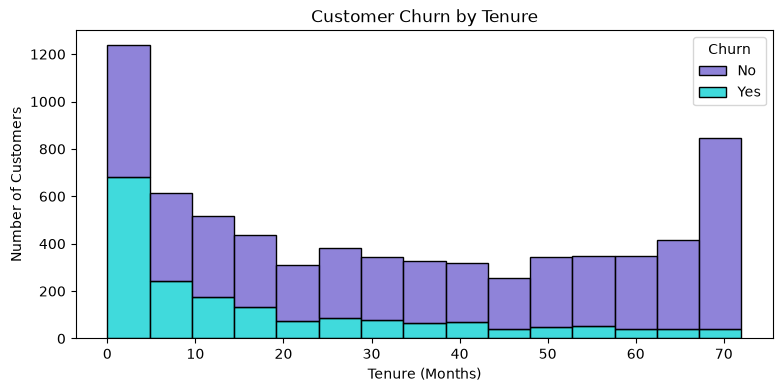

In [71]:
plt.figure(figsize=(9,4))

sns.histplot(
    x="tenure",
    data=df,
    bins=15,
    hue="Churn",
    multiple="stack",
    palette=["#6A5ACD", "#00CED1"]
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

people who have used our services for a long time have stayed and people who have used our sevices

1 or 2 months have churned

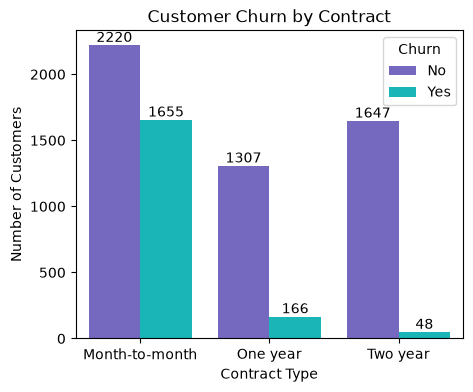

In [69]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    x="Contract",
    data=df,
    hue="Churn",
    palette=["#6A5ACD", "#00CED1"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Customer Churn by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

#people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 

In [72]:
df.columns.values

<ArrowStringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

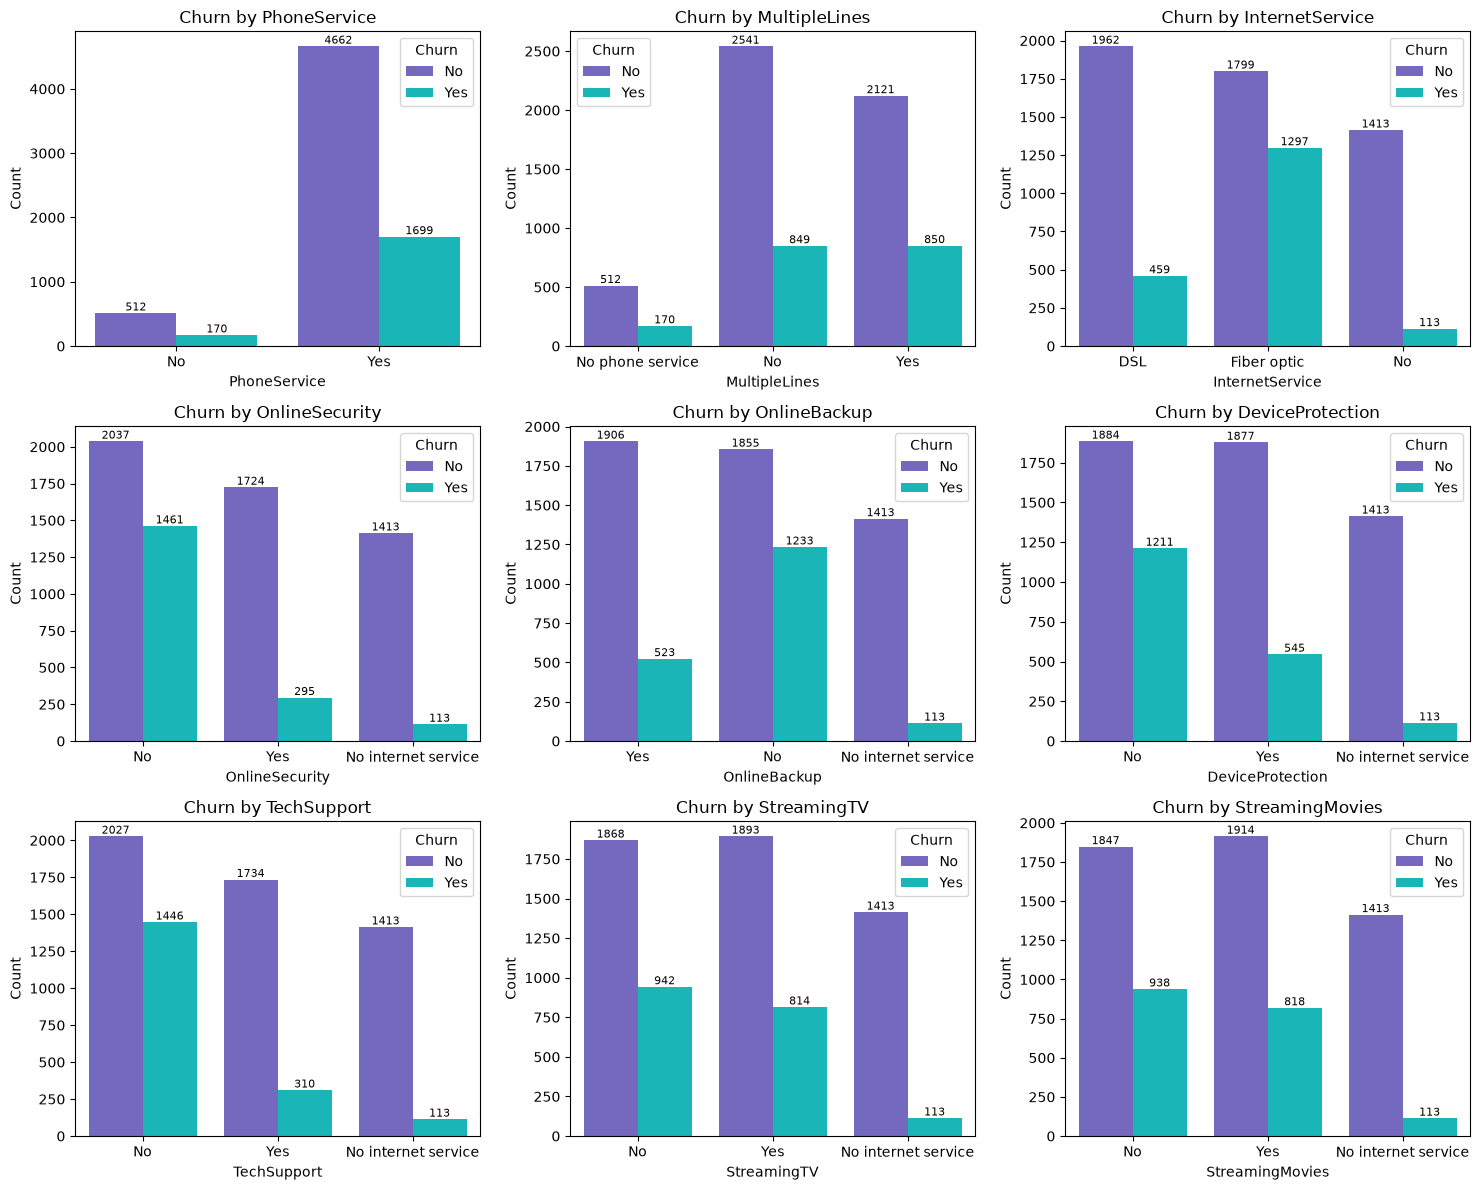

In [73]:
columns = ['PhoneService', 'MultipleLines', 'InternetService',
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies']

n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(columns):
    ax = sns.countplot(
        x=col,
        data=df,
        hue="Churn",
        ax=axes[i],
        palette=["#6A5ACD", "#00CED1"]
    )

    ax.set_title(f'Churn by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

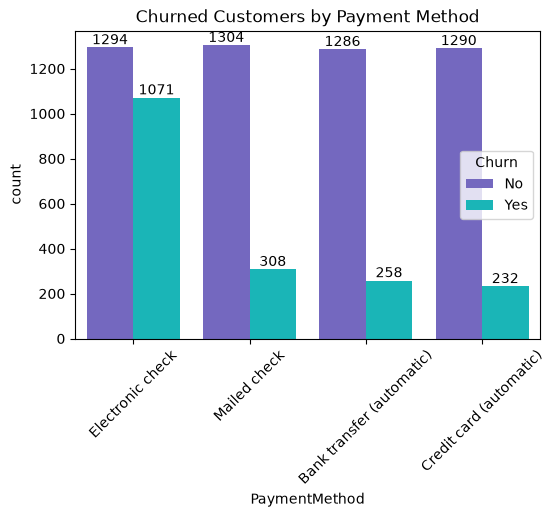

In [76]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="PaymentMethod",
    data=df,
    hue="Churn",
    palette=["#6A5ACD", "#00CED1"]
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Churned Customers by Payment Method")
plt.xticks(rotation=45)
plt.show()

customer is likely to churn when he is using electronic check as a payment method.